Importing libraries

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Loading the dataset

In [10]:
df = pd.read_csv("Titanic-Dataset.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


Data cleaning

In [11]:
print(df.info())
print(df.isnull().sum())

#removing unwanted columns
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'],
        axis=1,
        inplace=True)
print(df.info())

#handling missing values
df['Age'].fillna(df['Age'].median(), inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

#encoding categorical variables
encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int6

/tmp/ipykernel_906/2452714020.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_906/2452714020.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

Feature engineering

In [12]:
# Combine SibSp + Parch into one FamilySize feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Was the passenger alone?
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Reduce Fare skew with log transform
df['Fare'] = np.log1p(df['Fare'])

print(df[['FamilySize', 'IsAlone', 'Fare']].head(10))
print("Columns now:", df.columns.tolist())

   FamilySize  IsAlone      Fare
0           2        0  2.110213
1           2        0  4.280593
2           1        1  2.188856
3           2        0  3.990834
4           1        1  2.202765
5           1        1  2.246893
6           1        1  3.967694
7           5        0  3.094446
8           3        0  2.495954
9           2        0  3.436268
Columns now: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone']


Visualization

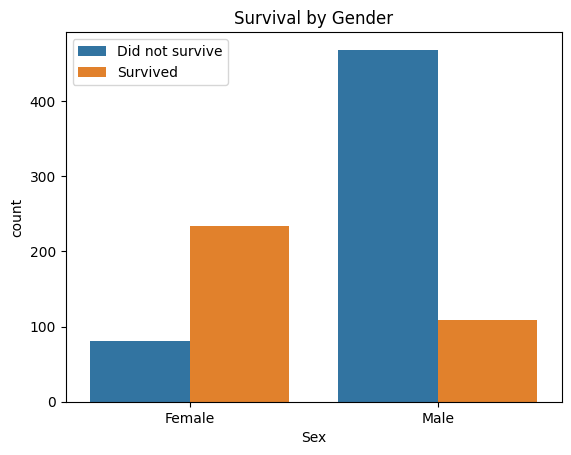

In [13]:
#Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.xticks([0,1], ['Female', 'Male'])
plt.legend(['Did not survive', 'Survived'])
plt.show()

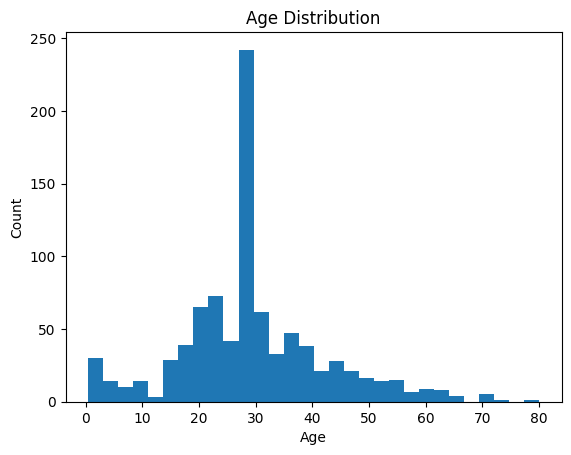

In [14]:
#Age distribution
plt.hist(df['Age'], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

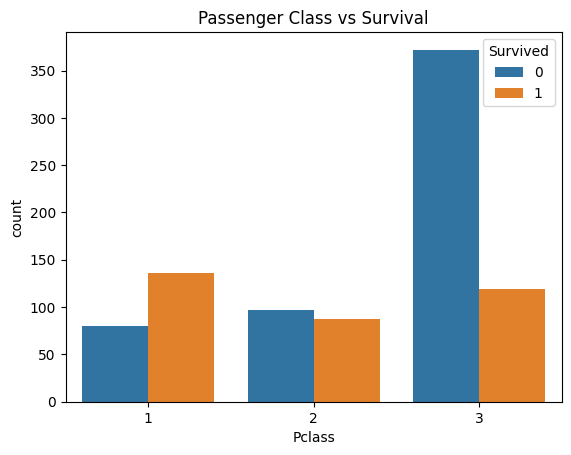

In [15]:
#Survival by Passenger class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Passenger Class vs Survival")
plt.show()

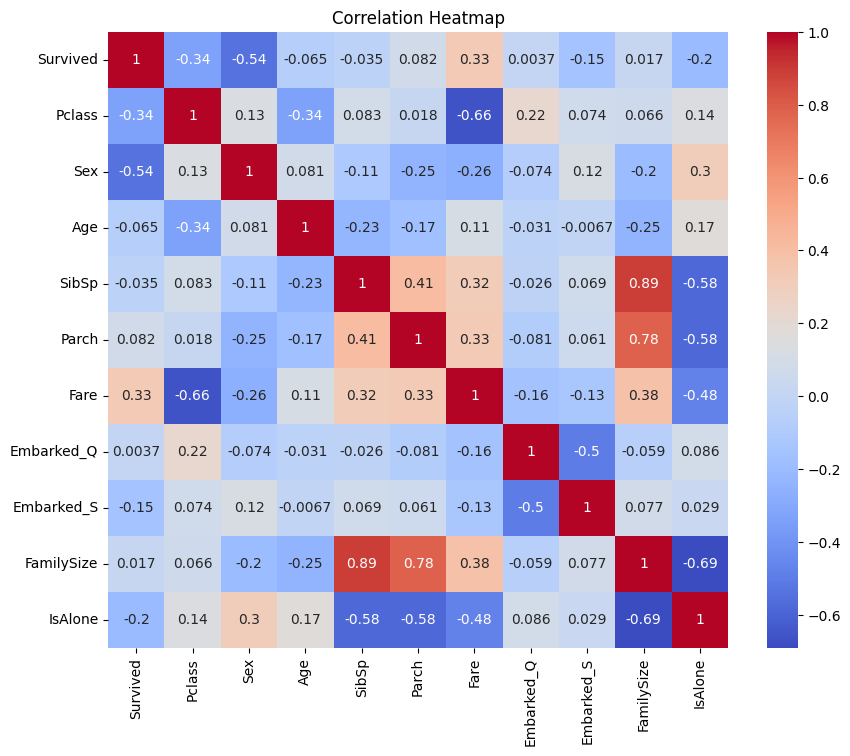

In [16]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Splitting training and test sets

In [17]:
# X = everything except Survived
# y = Survived column only
X = df.drop('Survived', axis=1)
y = df['Survived']

print("X shape:", X.shape)   # (891, 10)
print("y shape:", y.shape)   # (891,)
print("\nFeatures used:\n", X.columns.tolist())

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps survived ratio same in both splits
)

print("\nTraining rows:", X_train.shape[0])   # ~712
print("Testing rows :", X_test.shape[0])    # ~179
print("\nSurvival rate in train:", round(y_train.mean(), 3))
print("Survival rate in test :", round(y_test.mean(), 3))

X shape: (891, 10)
y shape: (891,)

Features used:
 ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone']

Training rows: 712
Testing rows : 179

Survival rate in train: 0.383
Survival rate in test : 0.385


Scaling the features

In [18]:
scaler = StandardScaler()

# Fit ONLY on training data, then transform both
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)    # ← never fit on test data!

print("First training row after scaling:")
print(X_train[0].round(3))

First training row after scaling:
[ 0.83   0.742 -0.112 -0.465 -0.466  1.125 -0.289  0.612 -0.556  0.8  ]


Training the first model (Logistic regression)

In [27]:
# Create and train
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train, y_train)

# Predict on test set
lr_preds = lr_model.predict(X_test)

# Evaluate
log_acc = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", round(log_acc, 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Did not survive', 'Survived']))

Logistic Regression Accuracy: 0.821

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.83      0.89      0.86       110
       Survived       0.80      0.71      0.75        69

       accuracy                           0.82       179
      macro avg       0.82      0.80      0.81       179
   weighted avg       0.82      0.82      0.82       179



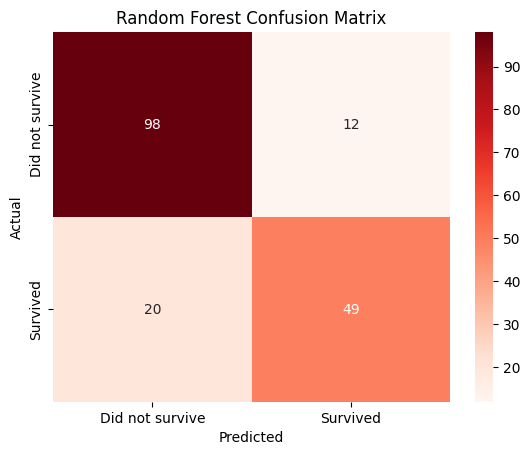

In [29]:
cm = confusion_matrix(y_test, lr_preds)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

Second Model (Decision Tree)

In [20]:
# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_preds = dt_model.predict(X_test)

# Accuracy
dt_acc = accuracy_score(y_test, dt_preds)

print("Decision Tree Accuracy:", round(dt_acc, 3))

print("\nClassification Report:")
print(classification_report(
    y_test,
    dt_preds,
    target_names=['Did not survive', 'Survived']
))

Decision Tree Accuracy: 0.799

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.83      0.85      0.84       110
       Survived       0.75      0.72      0.74        69

       accuracy                           0.80       179
      macro avg       0.79      0.79      0.79       179
   weighted avg       0.80      0.80      0.80       179



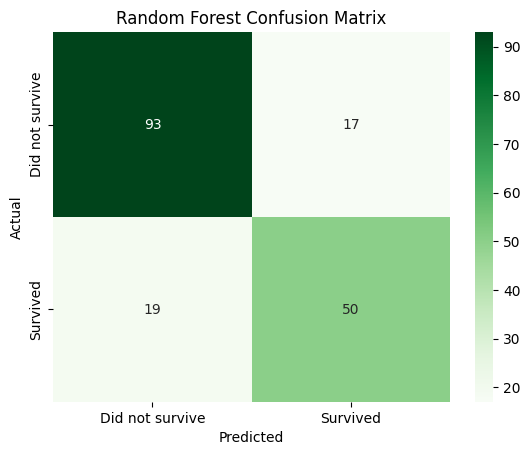

In [24]:
cm = confusion_matrix(y_test, dt_preds)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

Third Model (Random Forest)

In [21]:
# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)

# Accuracy
rf_acc = accuracy_score(y_test, rf_preds)

print("Random Forest Accuracy:", round(rf_acc, 3))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_preds,
    target_names=['Did not survive', 'Survived']
))
#

Random Forest Accuracy: 0.821

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.84      0.87      0.86       110
       Survived       0.78      0.74      0.76        69

       accuracy                           0.82       179
      macro avg       0.81      0.81      0.81       179
   weighted avg       0.82      0.82      0.82       179



Confusion matrix for RandomForest model

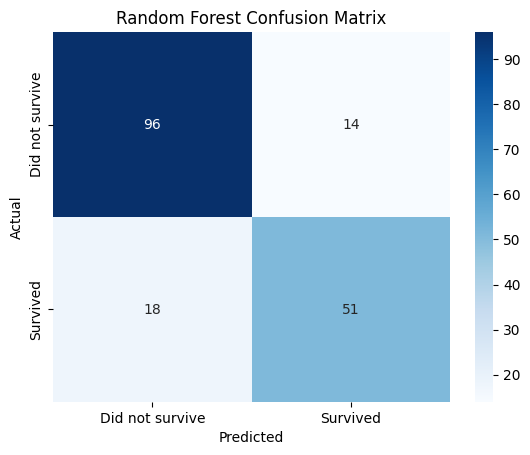

In [22]:
cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

Comparision of accuracy among thre models


In [23]:
print("\nModel Comparison")
print("-------------------------")
print("Logistic Regression :", round(log_acc, 3))
print("Decision Tree       :", round(dt_acc, 3))
print("Random Forest       :", round(rf_acc, 3))


Model Comparison
-------------------------
Logistic Regression : 0.821
Decision Tree       : 0.799
Random Forest       : 0.821


***Random Forest achieved the best performance for Titanic survival prediction.***